<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Taxi_price_Regression_ML_(Cross_Validation_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load and inspect the data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/taxi_price_regression_dataset.csv")
df.head()

,trip_id,distance_km,duration_min,base_fare,per_km_rate,per_min_rate,surge_multiplier,passenger_count,vehicle_type,payment_method,time_of_day,taxi_price
0,1,11.861663,77.015109,70.654533,8.830540,2.130352,1.2,2,SUV,Cash,Afternoon,407.362452
1,2,28.570715,47.033949,66.888015,15.028361,2.834706,2.0,2,SUV,UPI,Morning,1259.172932
2,3,22.227824,21.614577,54.572586,17.586425,1.396862,1.0,2,Sedan,UPI,Afternoon,475.673130
3,4,18.361096,67.614552,64.524886,17.173677,2.787348,1.2,2,Sedan,UPI,Morning,681.981257
4,5,5.524541,40.587642,55.556764,18.048754,1.812325,1.5,3,SUV,Card,Evening,343.238782


# Understand the Data Types and Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           50000 non-null  int64  
 1   distance_km       50000 non-null  float64
 2   duration_min      45000 non-null  float64
 3   base_fare         50000 non-null  float64
 4   per_km_rate       50000 non-null  float64
 5   per_min_rate      50000 non-null  float64
 6   surge_multiplier  50000 non-null  float64
 7   passenger_count   50000 non-null  int64  
 8   vehicle_type      50000 non-null  object 
 9   payment_method    50000 non-null  object 
 10  time_of_day       50000 non-null  object 
 11  taxi_price        50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


# Data Cleaning

In [ ]:
df.isnull().sum()

,0
trip_id,0
distance_km,0
duration_min,5000
base_fare,0
per_km_rate,0
per_min_rate,0
surge_multiplier,0
passenger_count,0
vehicle_type,0
payment_method,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(50000, 12)

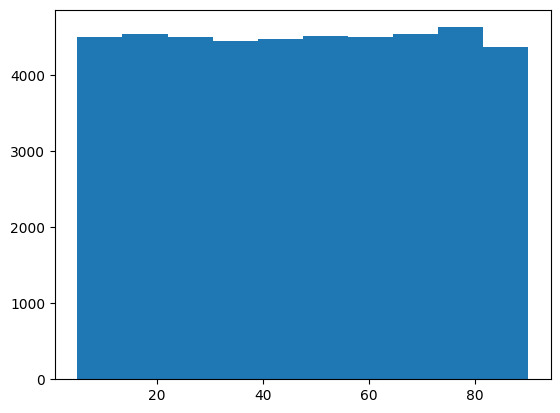

In [ ]:
plt.hist(df['duration_min'])
plt.show()

In [ ]:
df["duration_min"].fillna(df["duration_min"].median(),inplace=True)

/tmp/ipykernel_6185/2912680634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["duration_min"].fillna(df["duration_min"].median(),inplace=True)


# Visualization

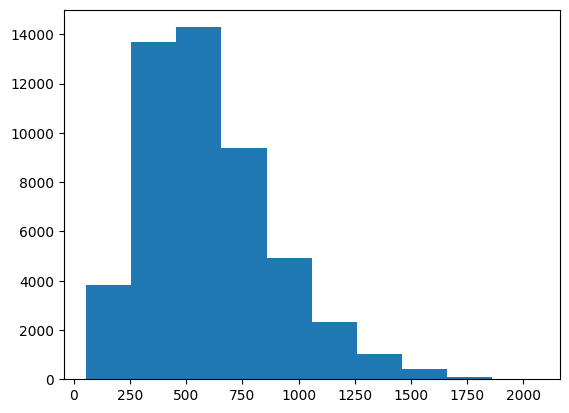

In [ ]:
plt.hist(df['taxi_price'])
plt.show()

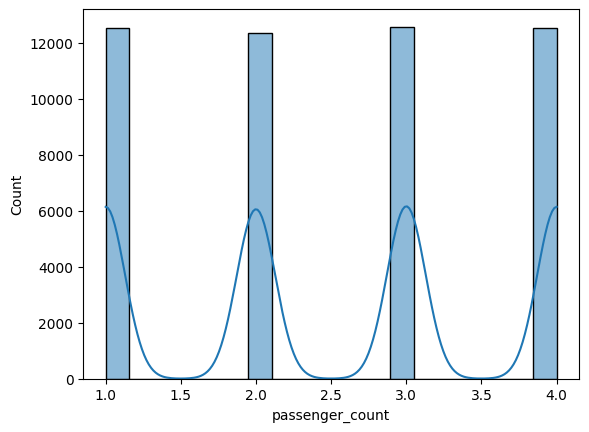

In [ ]:
sns.histplot(df["passenger_count"],kde=True)
plt.show()

# Correlation analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           50000 non-null  int64  
 1   distance_km       50000 non-null  float64
 2   duration_min      50000 non-null  float64
 3   base_fare         50000 non-null  float64
 4   per_km_rate       50000 non-null  float64
 5   per_min_rate      50000 non-null  float64
 6   surge_multiplier  50000 non-null  float64
 7   passenger_count   50000 non-null  int64  
 8   vehicle_type      50000 non-null  object 
 9   payment_method    50000 non-null  object 
 10  time_of_day       50000 non-null  object 
 11  taxi_price        50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


In [ ]:
print(df["vehicle_type"].unique())

['SUV' 'Sedan' 'Mini']


In [ ]:
print(df["payment_method"].unique())

['Cash' 'UPI' 'Card']


In [ ]:
print(df["time_of_day"].unique())

['Afternoon' 'Morning' 'Evening' 'Night']


In [ ]:
df["vehicle_type"].replace(['SUV','Sedan','Mini'],[0,1,2],inplace=True)

/tmp/ipykernel_6185/489358696.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["vehicle_type"].replace(['SUV','Sedan','Mini'],[0,1,2],inplace=True)
/tmp/ipykernel_6185/489358696.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["vehicle_type"].replace(['SUV','Sedan','Mini'],[0,1,2],inplac

In [ ]:
df["payment_method"].replace(['Cash','UPI','Card'],[0,1,2],inplace=True)

/tmp/ipykernel_6185/1353472414.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["payment_method"].replace(['Cash','UPI','Card'],[0,1,2],inplace=True)
/tmp/ipykernel_6185/1353472414.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["payment_method"].replace(['Cash','UPI','Card'],[0,1,2],in

In [ ]:
df["time_of_day"].replace(['Afternoon','Morning','Evening','Night'],[0,1,2,3],inplace=True)

/tmp/ipykernel_6185/1123537024.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["time_of_day"].replace(['Afternoon','Morning','Evening','Night'],[0,1,2,3],inplace=True)
/tmp/ipykernel_6185/1123537024.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["time_of_day"].replace(['Afternoon','Mo

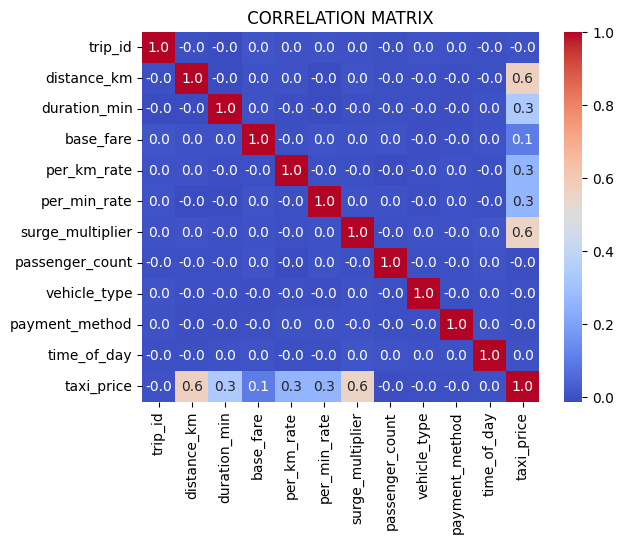

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt="0.1f",cmap="coolwarm")
plt.title(" CORRELATION MATRIX ")
plt.show()

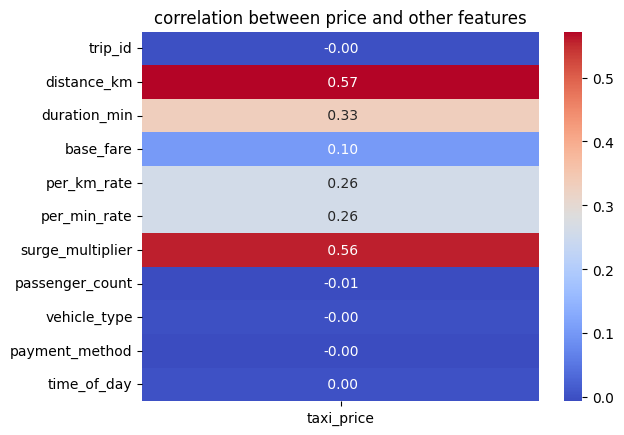

In [ ]:
status_corr=df.corr()["taxi_price"]
status_corr=status_corr.drop("taxi_price")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .2f",cmap= "coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other features")
plt.show()

In [ ]:
df.columns

Index(['trip_id', 'distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count', 'vehicle_type',
       'payment_method', 'time_of_day', 'taxi_price'],
      dtype='object')

In [ ]:
df.drop(["trip_id","time_of_day","payment_method","vehicle_type"],axis=1,inplace=True)

In [ ]:
df.shape

(50000, 8)

# Outlier Checking and removing

<Axes: >

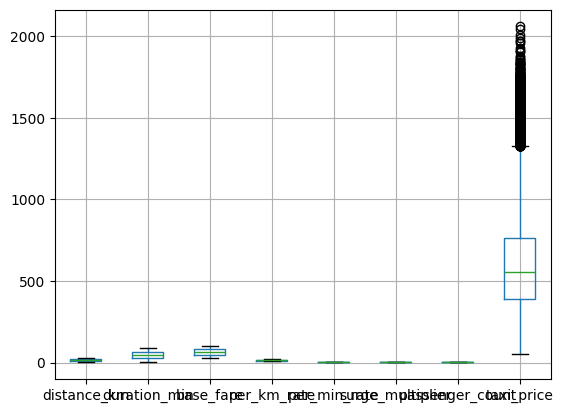

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
       continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR =Q3-Q1
    lower_bound = Q1 -1.5 *IQR
    upper_bound = Q3 +1.5 *IQR
    df=df[(df[col]>= lower_bound)&(df[col]<=upper_bound)]
  return df

df_cleaned= remove_outliers_iqr(df,exclude_column='taxi_price')
df=df_cleaned

In [ ]:
df.shape

(50000, 8)

# Data Scaling

In [ ]:
df.columns

Index(['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count', 'taxi_price'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features =['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

# After EDA .... our dataset is regression so use LinearRegression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.90


# DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeRegressor


x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.94


# SVM - SVR

In [ ]:
from sklearn.svm import SVR


x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=SVR(kernel="poly",degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.59


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor


x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.98


# ADABOOST

In [ ]:
from sklearn.ensemble import AdaBoostRegressor


x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=AdaBoostRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.78


# XGBOOST

In [ ]:
from  xgboost import XGBRegressor


x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=XGBRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.98
